In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
os.chdir("/Users/darylldalmeida/Documents/Data science/Datasets/Bank loan")

In [3]:
df = pd.read_csv("Creditcardfraud.csv")

In [4]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## EDA

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df['type'].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

## Insights 

- Cash withdrawals are the highest form of transactions made out of all the types of transactions.
- Debit card transactions are the lowest form of transactions.


In [9]:
df[df['step']==2].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2708,2,PAYMENT,1826.81,C70165127,24622.0,22795.19,M2026706491,0.0,0.0,0,0
2709,2,PAYMENT,7709.20,C520830206,52152.0,44442.80,M351216770,0.0,0.0,0,0
2710,2,PAYMENT,3023.16,C1705281026,178.0,0.00,M1967667267,0.0,0.0,0,0
2711,2,PAYMENT,3708.43,C862062296,0.0,0.00,M1589968642,0.0,0.0,0,0
2712,2,PAYMENT,8702.16,C521270862,20929.0,12226.84,M724525007,0.0,0.0,0,0


In [10]:
df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.00,0.00,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [11]:
df['step'].value_counts(ascending = False)

19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
432        4
706        4
693        4
112        2
662        2
Name: step, Length: 743, dtype: int64

## Insights

- There are a total of 743 steps which means that the data is for about 31 days(~ 1 month duration)

In [12]:
transaction_types = df['type'].value_counts().reset_index()

transaction_types.columns = ['Transaction Type', 'Count']

fig = px.bar(
    transaction_types, x = "Transaction Type", y = "Count", text = 'Count',color = "Transaction Type",title = 'Distribution of Transaction type', template = 'plotly_white'
)

fig.update_traces(texttemplate = '%{text:,}',textposition = 'outside')

fig.update_layout(
    xaxis_title = "Transaction Type",yaxis_title = "Count of Transactions",uniformtext_minsize = 8,uniformtext_mode = 'hide',  yaxis = dict(range=[0,transaction_types['Count'].max()* 1.1]))


fig.show()


In [13]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Count of Fraud vs non Fraud

In [14]:
fraud_counts = df['isFraud'].value_counts().reset_index()
fraud_counts.columns = ['isFraud','Count']

fraud_counts['isFraud'] = fraud_counts['isFraud'].map({0: 'Non-Fraud', 1 : 'Fraud'})

fig = px.bar(
    fraud_counts, x = 'isFraud', y = 'Count', text = 'Count', color = 'isFraud', title = 'Fraud vs Non-Fraud transactions',template = 'plotly_white')

fig.update_traces(texttemplate = '%{text:,}', textposition = 'outside')

fig.update_layout(xaxis_title = 'Class',yaxis_title = 'Count of Transactions',
                  yaxis = dict(range=[0,fraud_counts['Count'].max()* 1.1]))

fig.show()

In [15]:
total = fraud_counts['Count'].sum()
fraud_counts['Percentage'] = (fraud_counts['Count']/ total * 100).round(2)

fraud_counts

,isFraud,Count,Percentage
0,Non-Fraud,6354407,99.87
1,Fraud,8213,0.13


## Insights

- This is an example of an imbalanced dataset since the number of Fraud transactions are quite lower than non fraud & non fraud seems to be extremely high. It is also understandable that the dataset would be set up this way since the number of fraud transactions would be rare. 
- Finding accuracy here would not be a right metric to use. We should explore precision, recall , F1 score etc which i will work on in this project.

In [16]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Analyzing fraud distribution by transaction type

In [17]:
fraud_by_type = df.groupby(['type','isFraud']).size().reset_index(name= 'Count')

fraud_by_type['isFraud'] = fraud_by_type['isFraud'].map({0:"Non-Fraud",1: "Fraud"})

fig = px.bar(
    fraud_by_type, x = 'type', y = 'Count',
    color = 'isFraud',barmode = 'group',text = 'Count',
    title = 'Fraud vs non-Fraud Transaction type', template = 'plotly_white')

fig.update_traces(texttemplate = '%{text:,}',textposition = 'outside')

fig.update_layout(xaxis_title = 'Type', yaxis = dict(title = 'Count',
    range=[0,fraud_by_type['Count'].max()* 1.1]))

fig.show()

In [18]:
fraud_by_type

,type,isFraud,Count
0,CASH_IN,Non-Fraud,1399284
1,CASH_OUT,Non-Fraud,2233384
2,CASH_OUT,Fraud,4116
3,DEBIT,Non-Fraud,41432
4,PAYMENT,Non-Fraud,2151495
5,TRANSFER,Non-Fraud,528812
6,TRANSFER,Fraud,4097


## Insights

Fraud is observed only in two types:
- CASH_OUT ( ~ 4.1k fraud cases).
- TRANSFER ( ~ 4.1k fraud cases).
- PAYMENT, CASH_IN, DEBIT transactions never appear as fraudulent in this dataset.

In [19]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [20]:
fraud_cases = df[df['isFraud'] == 1]

fraud_cases.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,0
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,0


## Feature Engineering

- Adding a few features that can help me understand this dataset better in terms of old balance and new balance.

In [21]:
df['delta_org'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['delta_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [22]:
df['mismatch_org'] = (abs(df['delta_org'] - df['amount']) > 1e-6).astype(int)

df['mismatch_dest'] = (abs(df['delta_dest'] - df['amount']) > 1e-6).astype(int)

In [23]:
df[df['isFraud']== 1].shape

(8213, 15)

In [24]:
df[df['isFraud']== 1].head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0,181.00,0.00,0,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0,181.00,-21182.00,0,1
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,0,2806.00,0.00,0,1
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0,2806.00,-26202.00,0,1
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,0,20128.00,0.00,0,1
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0,20128.00,5877.85,0,1
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0,0.00,9291517.62,1,1
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0,1277212.77,0.00,0,1
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0,1277212.77,2444985.19,0,1
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,0,35063.63,0.00,0,1


In [25]:
df.groupby('isFraud')[['mismatch_org','mismatch_dest']].mean()*100

,mismatch_org,mismatch_dest
isFraud,,
0,80.660666,68.614491
1,0.547912,59.417996


## Insights

In this dataset non-fraud transactions show a higher mismatch rate than fraud transactions. This is because the company - PaySim cancels balances in fraud events, making balance-related features unreliable. For modeling, i would exclude these columns to avoid leakage.

In [26]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0,1


## Adding a new feature called Day of Month

In [27]:
df['day_of_month'] = (df['step'] // 24) + 1

In [28]:
df[['step','day_of_month']].head(30)

,step,day_of_month
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [29]:
df['step'].unique()[:50]   # see the first 50 unique step values


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

## Checking if the feature works

In [30]:
df[df['step']== 24].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
571039,24,PAYMENT,27003.49,C1828598998,324.00,0.00,M387058580,0.0,0.0,0,0,324.00,0.0,1,1,2
571040,24,PAYMENT,5655.98,C1782546301,30307.00,24651.02,M902526484,0.0,0.0,0,0,5655.98,0.0,0,1,2
571041,24,PAYMENT,10791.26,C672054527,325916.00,315124.74,M793205953,0.0,0.0,0,0,10791.26,0.0,0,1,2
571042,24,PAYMENT,24449.53,C1049758403,315124.74,290675.21,M1342677203,0.0,0.0,0,0,24449.53,0.0,0,1,2
571043,24,PAYMENT,11368.09,C229840744,557128.00,545759.91,M403174219,0.0,0.0,0,0,11368.09,0.0,0,1,2


In [31]:
df[df['step']== 25].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
574255,25,PAYMENT,19161.18,C1954261867,1589.0,0.00,M1085509720,0.0,0.0,0,0,1589.00,0.0,1,1,2
574256,25,PAYMENT,7725.76,C912521968,189169.0,181443.24,M1216280274,0.0,0.0,0,0,7725.76,0.0,0,1,2
574257,25,PAYMENT,7655.50,C1635204165,127302.0,119646.50,M1025130851,0.0,0.0,0,0,7655.50,0.0,0,1,2
574258,25,PAYMENT,15856.99,C336042058,119646.5,103789.51,M737162366,0.0,0.0,0,0,15856.99,0.0,0,1,2
574259,25,PAYMENT,1300.98,C1933422673,20559.0,19258.02,M474215948,0.0,0.0,0,0,1300.98,0.0,0,1,2


In [32]:
df[df['step']== 743].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.0,0.00,1,0,1258818.82,0.00,0,1,31
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.5,1762283.33,1,0,1258818.82,1258818.83,0,1,31
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.0,0.00,1,0,339682.13,0.00,0,1,31
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.0,339682.13,1,0,339682.13,339682.13,0,0,31
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.0,0.00,1,0,6311409.28,0.00,0,1,31


## Analyzing fraud by day

In [33]:
fraud_by_day = df.groupby('day_of_month')['isFraud'].sum().reset_index()

fig = px.line(
    fraud_by_day,x = 'day_of_month',y = 'isFraud', markers = True, text = 'isFraud' , title = 'Fraud Count per day of month' )

fig.update_traces(textposition = 'top center')

fig.update_layout(xaxis_title = 'Day of the month', yaxis_title = 'Fraud Count', template = 'plotly_white')

fig.show()

## Insights

- Fraud is not uniformly distributed across the month.
- This line chart shows fluctuations across these distributions with alot of spikes and dips in Fraud. 
- The peaks indicate high risk periods particularly on the 3rd to 4th day of the month followed by 7-8th and so on.

In [34]:
fraud_by_day = df.groupby('day_of_month')['isFraud'].sum().reset_index()
fraud_by_day.head(10) 


,day_of_month,isFraud
0,1,265
1,2,305
2,3,306
3,4,272
4,5,244
5,6,230
6,7,280
7,8,270
8,9,259
9,10,274


In [35]:
top_spikes = fraud_by_day.sort_values(by = 'isFraud',ascending=False).head(5)

top_spikes.head()

,day_of_month,isFraud
16,17,316
2,3,306
1,2,305
11,12,296
30,31,282


In [36]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0,1,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0,1,1


In [37]:
spike_days = [17,3,2,12,31]

df_spike = df[df['day_of_month'].isin(spike_days)]


df_spike[df_spike['day_of_month']==17].head(10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
5558063,384,PAYMENT,856.26,C1313287211,41625.00,40768.74,M35864941,0.00,0.0,0,0,856.26,0.00,0,1,17
5558064,384,PAYMENT,9751.52,C1208543866,40768.74,31017.22,M396796734,0.00,0.0,0,0,9751.52,0.00,0,1,17
5558065,384,PAYMENT,46714.49,C1618473877,31017.22,0.00,M2026368735,0.00,0.0,0,0,31017.22,0.00,1,1,17
5558066,384,PAYMENT,3455.84,C1997766791,11325.00,7869.16,M1435398664,0.00,0.0,0,0,3455.84,0.00,0,1,17
5558067,384,PAYMENT,6817.78,C171628663,20409.00,13591.22,M1305243385,0.00,0.0,0,0,6817.78,0.00,0,1,17
5558068,384,PAYMENT,8156.88,C649123967,12090.00,3933.12,M581779,0.00,0.0,0,0,8156.88,0.00,0,1,17
5558069,384,PAYMENT,7738.69,C1554872709,15627.00,7888.31,M1924689743,0.00,0.0,0,0,7738.69,0.00,0,1,17
5558070,384,PAYMENT,6688.59,C1391141447,963.00,0.00,M362826993,0.00,0.0,0,0,963.00,0.00,1,1,17
5558071,384,PAYMENT,2334.32,C586575505,169480.00,167145.68,M319139735,0.00,0.0,0,0,2334.32,0.00,0,1,17
5558072,384,CASH_IN,100390.24,C410476202,11182.00,111572.24,C689331267,14883.45,0.0,0,0,-100390.24,-14883.45,1,1,17


In [38]:
df_spike[df_spike['day_of_month']==17].shape

(421098, 16)

In [39]:
df_spike[df_spike['day_of_month']==2].shape

(452761, 16)

In [40]:
df_spike['isFraud'].value_counts()

0    1229185
1       1505
Name: isFraud, dtype: int64

## Analyzing fraud spike breakdown for these days

In [41]:
df_spike_filtered = df_spike[df_spike['type'].isin(['CASH_OUT','TRANSFER'])]

In [42]:
fraud_spike = df_spike_filtered.groupby(['day_of_month','type','isFraud']).size().reset_index(name='Count')
fraud_spike

,day_of_month,type,isFraud,Count
0,2,CASH_OUT,0,164169
1,2,CASH_OUT,1,154
2,2,TRANSFER,0,37914
3,2,TRANSFER,1,151
4,3,CASH_OUT,0,956
5,3,CASH_OUT,1,153
6,3,TRANSFER,0,542
7,3,TRANSFER,1,153
8,12,CASH_OUT,0,121346
9,12,CASH_OUT,1,148


In [43]:
fraud_rate = (df_spike_filtered.groupby(['day_of_month','type'])['isFraud'].mean()*100).reset_index()

fraud_rate


,day_of_month,type,isFraud
0,2,CASH_OUT,0.093718
1,2,TRANSFER,0.396690
2,3,CASH_OUT,13.796213
3,3,TRANSFER,22.014388
4,12,CASH_OUT,0.121817
5,12,TRANSFER,0.531743
6,17,CASH_OUT,0.104332
7,17,TRANSFER,0.449234
8,31,CASH_OUT,100.000000
9,31,TRANSFER,100.000000


## Insights

- Day 2 shows us that Fraud % rate for CASH_OUT & TRANSFER were very less <1%.
- Day 3 shows us that there was a significant increase in frauds occuring in CASH OUT & TRANSFER with the rates being 13.7% & 22% respectively.
- Day 12 shows us that the % rate dropped to a lower level <1%.
- Day 17 shows us that the trend was similar.
- Day 31 shows us that every single transaction for CASH_OUT and TRANSFER were fraudulent as they both have a 100% rate.

In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

- Our Fraud types are from CASH OUT & TRANSFER so here we will include only those transaction types.

In [45]:
X = df.drop('isFraud',axis = 1)
y = df['isFraud']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state= 42)

print("Before SMOTE:", y_train.value_counts())

Before SMOTE: 0    5083526
1       6570
Name: isFraud, dtype: int64


In [49]:
X_train.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFlaggedFraud      int64
delta_org         float64
delta_dest        float64
mismatch_org        int64
mismatch_dest       int64
day_of_month        int64
dtype: object

In [50]:
X = df.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Apply One-Hot Encoding to 'type'
X = pd.get_dummies(X, columns=['type'], drop_first=True)

# Check the new columns
print(X.columns)

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFlaggedFraud', 'delta_org', 'delta_dest',
       'mismatch_org', 'mismatch_dest', 'day_of_month', 'type_CASH_OUT',
       'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')


In [51]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before SMOTE:", y_train.value_counts())


Before SMOTE: 0    5083526
1       6570
Name: isFraud, dtype: int64


In [53]:
smte = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smte.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts())

After SMOTE: 0    5083526
1     508352
Name: isFraud, dtype: int64


In [54]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

print("\nInsights:")
print("- Fraud cases were extremely rare before SMOTE, ~0.13% of total.")
print("- After SMOTE, fraud cases represent ~10% of non-fraud.")
print("- This gives the model a better chance to learn fraud patterns,")
print("  but evaluation will still be done on the original imbalanced test set.")


Before SMOTE: 0    5083526
1       6570
Name: isFraud, dtype: int64
After SMOTE: 0    5083526
1     508352
Name: isFraud, dtype: int64

Insights:
- Fraud cases were extremely rare before SMOTE, ~0.13% of total.
- After SMOTE, fraud cases represent ~10% of non-fraud.
- This gives the model a better chance to learn fraud patterns,
  but evaluation will still be done on the original imbalanced test set.


## Creating a baseline model

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc


In [56]:
baselinemodel = LogisticRegression(max_iter=1000, class_weight=None, random_state=42)
baselinemodel.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
y_pred = baselinemodel.predict(X_test)

y_probability = baselinemodel.predict_proba(X_test)[:,1]

## Evaluating performance

Confusion Matrix: 


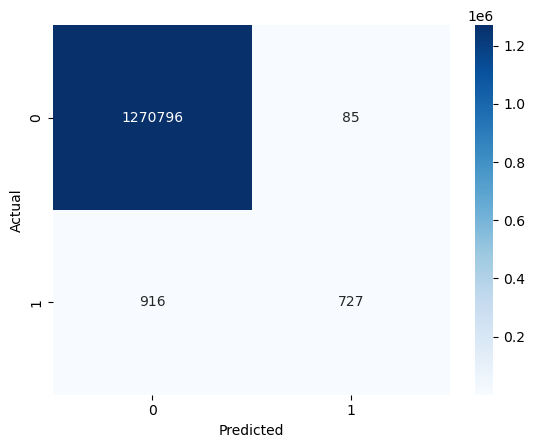


 Classification Report (Baseline - Before SMOTE ): 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.90      0.44      0.59      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.72      0.80   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9795


In [58]:
print("Confusion Matrix: ")
confusionmatrix = confusion_matrix(y_test,y_pred)

sns.heatmap(confusionmatrix,annot=True, fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\n Classification Report (Baseline - Before SMOTE ): ")
print(classification_report(y_test,y_pred))

roc_auc = roc_auc_score(y_test,y_probability)
print(f"ROC-AUC Score: {roc_auc:.4f}")

### Insight (Baseline Model - Before SMOTE)

- The baseline Logistic Regression model achieves ~100% accuracy, but this is misleading due to extreme class imbalance.  
- **Precision for fraud (Class 1) is 0.90** -> when the model predicts fraud, it is usually correct.  

- **Recall for fraud (Class 1) is only 0.44** -> the model misses more than half of all fraudulent transactions.  
- **AUC score is 0.98**, showing that the model can separate fraud from non-fraud in probability ranking, but the default threshold (0.5) leads to poor recall.  
- **Takeaway:** The model is biased toward the majority class (legit transactions). While it rarely mislabels legit cases, it misses a large number of fraud cases, which is unacceptable in fraud detection.  
- This highlights the need for SMOTE (or other balancing methods) to improve recall, even at the cost of some precision.


## Baseline Model After SMOTE

In [59]:
after_smote = LogisticRegression(max_iter=1000, random_state=42)

after_smote.fit(X_train_res, y_train_res)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_pred_smote = after_smote.predict(X_test)
y_proba_smote = after_smote.predict_proba(X_test)[:, 1]


In [61]:

print("Classification Report (Baseline - After SMOTE):")
print(classification_report(y_test, y_pred_smote))

roc_auc_smote = roc_auc_score(y_test, y_proba_smote)
print(f"ROC-AUC Score (After SMOTE): {roc_auc_smote:.4f}")

Classification Report (Baseline - After SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.17      0.80      0.29      1643

    accuracy                           0.99   1272524
   macro avg       0.59      0.90      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC Score (After SMOTE): 0.9922


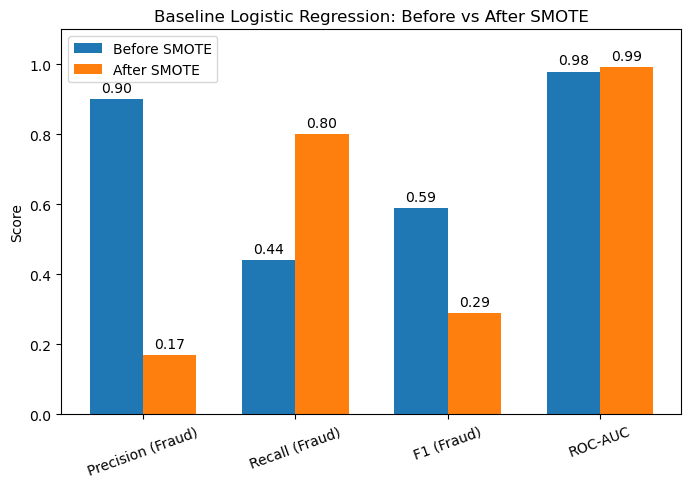

In [62]:
metrics = ['Precision (Fraud)', 'Recall (Fraud)', 'F1 (Fraud)', 'ROC-AUC']
before = [0.90, 0.44, 0.59, 0.9795]
after = [0.17, 0.80, 0.29, 0.9922]


x = np.arange(len(metrics))  
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, before, width, label='Before SMOTE')
rects2 = ax.bar(x + width/2, after, width, label='After SMOTE')

ax.set_ylabel('Score')
ax.set_title('Baseline Logistic Regression: Before vs After SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=20)
ax.set_ylim(0, 1.1)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

## Insights

- Missed frauds (low recall) directly cost money, while false alarms (low precision) only cause temporary inconvenience.

- High recall ensures the system catches most fraud attempts, even if it means investigating more flagged cases.

## Model Selection

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score

In [64]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_res,y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report (Random Forest - After SMOTE):")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest - After SMOTE): {roc_auc_rf:.4f}")

Classification Report (Random Forest - After SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score (Random Forest - After SMOTE): 0.9991


## Insights

- The model shows extremely good accuracy and is too good to be true. I am assuming there are other contributing factors as to why the accuracy shows so high. It looks like the model is overfitting.

In [66]:
pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)


delta_org         0.260136
mismatch_org      0.199591
newbalanceOrig    0.197433
amount            0.081871
oldbalanceOrg     0.062361
type_TRANSFER     0.043194
newbalanceDest    0.036365
delta_dest        0.033608
step              0.026525
type_PAYMENT      0.017525
day_of_month      0.016894
type_CASH_OUT     0.008081
mismatch_dest     0.007549
oldbalanceDest    0.007542
isFlaggedFraud    0.000901
type_DEBIT        0.000423
dtype: float64

In [67]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,delta_org,delta_dest,mismatch_org,mismatch_dest,day_of_month
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0,1,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0,1,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0,1,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,0,1,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0,1,1


- These top 2-3 columns make up for almost 66% of the model’s decisions. I will drop them since i feel that there could be a data leakage problem and that may be the reason why our model shows such high accuracy.

In [68]:
leakage_cols =  ['oldbalanceOrg',
    'newbalanceOrig',
    'newbalanceDest',
    'delta_org',
    'mismatch_org',
    'mismatch_dest',
    'delta_dest'
]


In [69]:
X = df.drop(['isFraud', 'nameOrig', 'nameDest'] + leakage_cols, axis=1)
y = df['isFraud']

In [70]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [71]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE: ",y_train.value_counts())
print("After SMOTE: ",y_train_res.value_counts())

Before SMOTE:  0    5083526
1       6570
Name: isFraud, dtype: int64
After SMOTE:  0    5083526
1     508352
Name: isFraud, dtype: int64


In [72]:
logistic_reg = LogisticRegression(max_iter=1000,random_state=42)

logistic_reg.fit(X_train_res, y_train_res)

y_pred_log = logistic_reg.predict(X_test)

In [73]:
y_prob_log = logistic_reg.predict_proba(X_test)[:,1]

In [74]:
print("Logistic Regression (After SMOTE, No Leakage):")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))


Logistic Regression (After SMOTE, No Leakage):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.05      0.25      0.08      1643

    accuracy                           0.99   1272524
   macro avg       0.52      0.62      0.54   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC: 0.8223091758628562


In [77]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest (After SMOTE, No Leakage):")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Random Forest (After SMOTE, No Leakage):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.14      0.69      0.24      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.84      0.62   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC: 0.9450631077286294


In [78]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [79]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, y_pred_log,pos_label = 1),
    "Recall": recall_score(y_test, y_pred_log,pos_label = 1),
    "F1-Score": f1_score(y_test, y_pred_log,pos_label = 1),
    "ROC-AUC": roc_auc_score(y_test,y_prob_log)
})

results.append({
     "Model": "Random Forest",
    "Precision": precision_score(y_test, y_pred_rf, pos_label=1),
    "Recall": recall_score(y_test, y_pred_rf, pos_label=1),
    "F1-Score": f1_score(y_test, y_pred_rf, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
})

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.046871  0.247109  0.078797  0.822309
1        Random Forest   0.143758  0.693853  0.238170  0.945063


## Insights

- Random Forest outperforms Logistic Regression in terms of Precision, Recall, F1-Score & ROC-AUC score. I will compare this Random Forest Model to XGBoost to compare them now.

In [80]:
from xgboost import XGBClassifier

In [81]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, scale_pos_weight=1       
)

xgb.fit(X_train_res, y_train_res)


y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]


results.append({
    "Model": "XGBoost",
    "Precision": precision_score(y_test, y_pred_xgb, pos_label=1),
    "Recall": recall_score(y_test, y_pred_xgb, pos_label=1),
    "F1-Score": f1_score(y_test, y_pred_xgb, pos_label=1),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb)
})

In [82]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.046871  0.247109  0.078797  0.822309
1        Random Forest   0.143758  0.693853  0.238170  0.945063
2              XGBoost   0.114547  0.716981  0.197535  0.979069


## Hyperparameter Tuning

In [83]:
from sklearn.model_selection import RandomizedSearchCV


In [86]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [50, 100], "max_depth": [5, 10, None], "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=2)  

rf_search = RandomizedSearchCV( rf, param_grid_rf, n_iter=5, scoring="recall", cv=2, verbose=1, random_state=42, n_jobs=2)


X_sample = X_train_res.sample(n=50000, random_state=42)
y_sample = y_train_res.loc[X_sample.index]

rf_search.fit(X_sample, y_sample)
print("Best RF Params:", rf_search.best_params_)


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best RF Params: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': None}


In [87]:
rf_final = RandomForestClassifier(
    n_estimators=100, max_features='sqrt', max_depth= None, random_state=42, n_jobs=2
)

rf_final.fit(X_train_res, y_train_res)

y_pred_rf_final = rf_final.predict(X_test)
y_proba_rf_final = rf_final.predict_proba(X_test)[:,1]

print("Random Forest (Tuned ): ")
print(classification_report(y_test,y_pred_rf_final))
print("ROC-AUC: ", roc_auc_score(y_test, y_proba_rf_final))

Random Forest (Tuned ): 
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.14      0.69      0.24      1643

    accuracy                           0.99   1272524
   macro avg       0.57      0.84      0.62   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC:  0.9450631077286294


In [88]:
param_grid_xgb = {"n_estimators": [100,200,300],"max_depth": [3,5,7],"learning_rate": [0.01,0.05,0.1],
                  "subsample": [0.7,0.8,1.0],"colsample_bytree": [0.7,0.8,1.0]}

xgb = XGBClassifier(
    objective = "binary:logistic",eval_metric = "logloss",random_state = 42, n_jobs = 2
)

xgb_search = RandomizedSearchCV(xgb, param_distributions=param_grid_xgb,n_iter = 7, scoring = "recall",cv = 3,verbose = 1, random_state=42, n_jobs = 2)

xgb_search.fit(X_train_res, y_train_res)

print("Best XGBoost Params:", xgb_search.best_params_)

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [90]:
xgb_final = XGBClassifier(
    subsample = 0.8, n_estimators = 200, max_depth = 7, learning_rate = 0.1,colsample_bytree = 1.0,objective = "binary:logistic",
    eval_metric = "logloss",random_state = 42, n_jobs = 2
)

xgb_final.fit(X_train_res,y_train_res)

y_pred_xgb = xgb_final.predict(X_test)
y_proba_xgb = xgb_final.predict_proba(X_test)[:,1]

print("XGBoost (Final, Tuned):")
print(classification_report(y_test,y_pred_xgb))
print("ROC-AUC:",roc_auc_score(y_test,y_proba_xgb))

XGBoost (Final, Tuned):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.12      0.71      0.20      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.85      0.60   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC-AUC: 0.9778864950433933


## Results

In [98]:
def performance_metrics_table(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,"Precision": precision_score(y_true,y_pred, pos_label = 1),
        "Recall": recall_score(y_true,y_pred,pos_label = 1),
        "F1-Score": f1_score(y_true,y_pred,pos_label=1),
        "ROC-AUC": roc_auc_score(y_true,y_proba)
    }

results = []

results.append(performance_metrics_table(y_test,y_pred_log,y_prob_log,"Logistic Regression(After SMOTE)"))

results.append(performance_metrics_table(y_test,y_pred_rf_final,y_proba_rf_final,"Random Forest (Tuned)"))

results.append(performance_metrics_table(y_test,y_pred_xgb,y_proba_xgb,"XGBoost (Tuned)"))

results_df = pd.DataFrame(results)

print(results_df)

                              Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression(After SMOTE)   0.046871  0.247109  0.078797  0.822309
1             Random Forest (Tuned)   0.143758  0.693853  0.238170  0.945063
2                   XGBoost (Tuned)   0.117819  0.712721  0.202210  0.977886


In [99]:
y_pred_xgb = xgb_final.predict(X_test)


In [100]:
# Get probabilities for fraud class (1)
y_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

# Apply custom threshold (e.g., 0.3 instead of 0.5)
threshold = 0.3
y_pred_custom = (y_proba_xgb >= threshold).astype(int)


In [95]:

print(classification_report(y_test, y_pred_custom))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.80      0.10      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.89      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524

ROC-AUC: 0.9778864950433933


## Insights

- I am choosing threshold = 0.3 because catching 80% of frauds outweighs the cost of handling extra false alarms. 

In [102]:

# XGBoost (Tuned, 0.5 cutoff)
results.append(performance_metrics_table(
    y_test, y_pred_xgb, y_proba_xgb, "XGBoost (Tuned, 0.5)"
))

# XGBoost (Tuned, custom threshold 0.3)
threshold = 0.3
y_pred_xgb_custom = (y_proba_xgb >= threshold).astype(int)
results.append(performance_metrics_table(
    y_test, y_pred_xgb_custom, y_proba_xgb, "XGBoost (Tuned, 0.3)"
))

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                               Model  Precision    Recall  F1-Score   ROC-AUC
0   Logistic Regression(After SMOTE)   0.046871  0.247109  0.078797  0.822309
1              Random Forest (Tuned)   0.143758  0.693853  0.238170  0.945063
2                    XGBoost (Tuned)   0.117819  0.712721  0.202210  0.977886
3  Logistic Regression (After SMOTE)   0.046871  0.247109  0.078797  0.822309
4         Random Forest (Tuned, 0.5)   0.143758  0.693853  0.238170  0.945063
5               XGBoost (Tuned, 0.5)   0.117819  0.712721  0.202210  0.977886
6               XGBoost (Tuned, 0.3)   0.055406  0.799757  0.103632  0.977886
7               XGBoost (Tuned, 0.5)   0.117819  0.712721  0.202210  0.977886
8               XGBoost (Tuned, 0.3)   0.055406  0.799757  0.103632  0.977886


In [103]:
results_df = results_df.drop_duplicates().reset_index(drop=True)
print(results_df)

                               Model  Precision    Recall  F1-Score   ROC-AUC
0   Logistic Regression(After SMOTE)   0.046871  0.247109  0.078797  0.822309
1              Random Forest (Tuned)   0.143758  0.693853  0.238170  0.945063
2                    XGBoost (Tuned)   0.117819  0.712721  0.202210  0.977886
3  Logistic Regression (After SMOTE)   0.046871  0.247109  0.078797  0.822309
4         Random Forest (Tuned, 0.5)   0.143758  0.693853  0.238170  0.945063
5               XGBoost (Tuned, 0.5)   0.117819  0.712721  0.202210  0.977886
6               XGBoost (Tuned, 0.3)   0.055406  0.799757  0.103632  0.977886


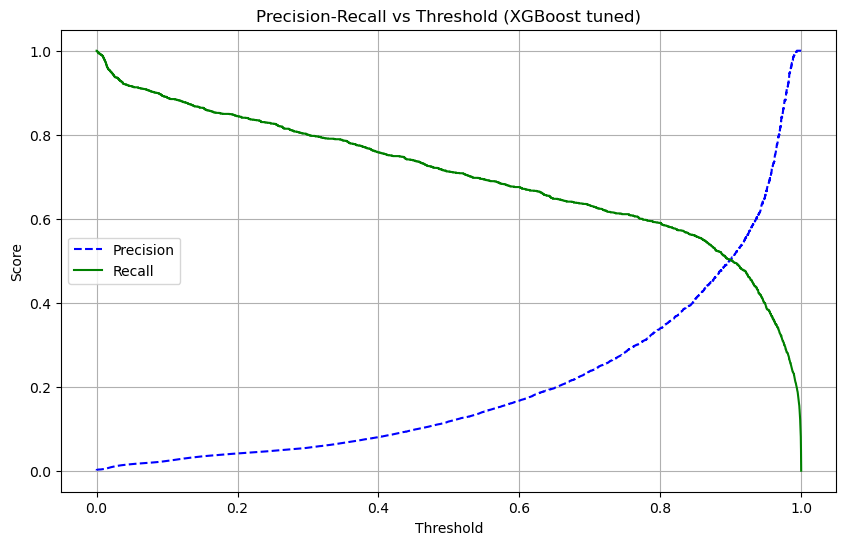

In [107]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10,6))
plt.plot(thresholds,precisions[:-1],"b--",label = "Precision")
plt.plot(thresholds,recalls[:-1],"g-",label = "Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold (XGBoost tuned)")
plt.legend()
plt.grid(True)
plt.show()

## Insights

- In Fraud Detection, we should be looking to maximize recall since we do not want to miss on frauds.
- When we are lowering the threshold from 0.5 to 0.3 that will help us maximize on catching frauds and increasing recall %. 
- When the precision increases in such a scenario, it is considered as an acceptable trade-off for the business.

## Confusion Matrix for XGB at Threshold = 0.3

<Figure size 600x600 with 0 Axes>

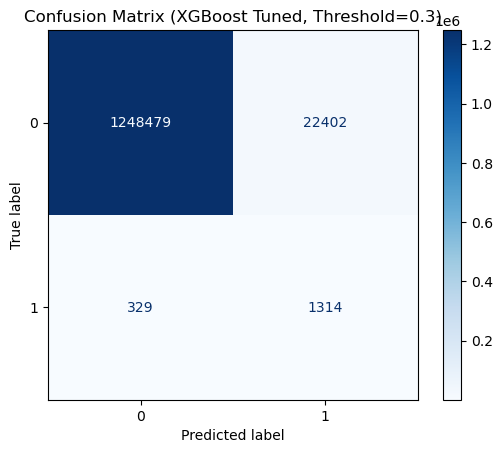

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay


threshold = 0.3
y_pred_xgb_custom = (y_proba_xgb >= threshold).astype(int)

conf_matrix = confusion_matrix(y_test, y_pred_xgb_custom)

display_matrix = ConfusionMatrixDisplay(confusion_matrix = conf_matrix,display_labels = [0,1])

plt.figure(figsize = (6,6))
display_matrix.plot(cmap="Blues",values_format = "d")
plt.title("Confusion Matrix (XGBoost Tuned, Threshold=0.3)")
plt.show()



- The final XGBoost model at threshold=0.3 correctly identified 1,314 fraud cases (~80%) while missing 329. 
- It raised 22,402 false alarms among total transactions.

## Conclusion

- After comparing multiple models (Logistic Regression, Random Forest, XGBoost) with SMOTE and hyperparameter tuning, the final selected model is XGBoost (tuned) with a 0.3 threshold.

- This configuration achieves ~80% recall, catching the majority of fraud cases while accepting a higher number of false positives.

- Trying to show this from a business perspective, since missing fraud is far costlier than investigating false alarms, this trade-off is justified. 

- The final model delivers a strong(ROC-AUC ≈ 0.978) and provides a reliable foundation for fraud detection deployment. 